# BiLSTM-CRF Named Entity Recognition (Keras/TensorFlow, pure-TF CRF)

This notebook trains a BiLSTM encoder with a custom linear-chain CRF implemented in pure TensorFlow, and evaluates it with `seqeval`.

**Dataset**
- **Babelscape/wikineural (English)** using the provided `train_en`, `val_en`, and `test_en` splits.
- Labels follow a 9-label BIO schema: `O, B/I-PER, B/I-ORG, B/I-LOC, B/I-MISC`.

**What you get**
- Token-level preprocessing with learned embeddings (`PAD`/`UNK` handling).
- BiLSTM sequence encoder + CRF decoding (Viterbi), with SpatialDropout and mild L2 regularization.
- Training curves (loss, generalization gap, learning rate) and `seqeval` validation/test reports.
- Simple `predict_sentence(...)` and `bio_spans(...)` helpers for quick inspection.

**How to tweak**
- Model knobs: `EMBED_DIM`, `LSTM_UNITS`, `DROPOUT`, `EMBED_DROPOUT`, `L2_WEIGHT`, `MAX_LEN`.
- Optional on-the-fly word-dropout (`AUG_P`) in the input pipeline to improve generalization.

We use the dataset [Babelscape/wikineural](https://huggingface.co/Babelscape/wikineural-multilingual-ner)

**Several sections of this notebook have been generated with GPT-5**


# Guide to BIO Tags

---

**1. What are BIO tags?**

BIO is a scheme for labeling which tokens belong to entities and where those entities start and end.

* `B-XXX` means the beginning of an entity of type `XXX`
* `I-XXX` means inside (continuation) of that same entity
* `O` means outside any entity

For NER, `XXX` is usually something like:

* `PER` – person
* `ORG` – organization
* `LOC` – location
* `MISC` – miscellaneous entity

So a typical tagset is:

`O`, `B-PER`, `I-PER`, `B-ORG`, `I-ORG`, `B-LOC`, `I-LOC`, `B-MISC`, `I-MISC`

---

**2. Example of BIO tagging**

Sentence:

> Barack Obama visited Paris with Apple executives .

Indexing tokens (0-based):

| idx | token      |
| --- | ---------- |
| 0   | Barack     |
| 1   | Obama      |
| 2   | visited    |
| 3   | Paris      |
| 4   | with       |
| 5   | Apple      |
| 6   | executives |
| 7   | .          |

One possible BIO tagging:

| token      | tag      | meaning                     |
| ---------- | -------- | --------------------------- |
| Barack     | `B-PER`  | start of a person entity    |
| Obama      | `I-PER`  | continuation of that person |
| visited    | `O`      | not an entity               |
| Paris      | `B-LOC`  | start of a location entity  |
| with       | `O`      | not an entity               |
| Apple      | `B-MISC` | start of a misc-type entity |
| executives | `O`      | not an entity               |
| .          | `O`      | not an entity               |

From these tags we can reconstruct entity spans (using `[start, end)` notation):

* `PER(0, 2)` → “Barack Obama”
* `LOC(3, 4)` → “Paris”
* `MISC(5, 6)` → “Apple”

---

**3. Basic BIO rules**

BIO tagging follows a few simple structural rules:

1. `O` means “no entity at this token.”

2. `B-XXX` starts a new entity of type `XXX`.

   * It can follow `O` or any other tag (ending the previous entity and starting a new one).

3. `I-XXX` continues an entity of type `XXX`.

   * It should follow either `B-XXX` or `I-XXX` of the same type.
   * If it follows `O` or a different type (for example, `B-PER` followed by `I-ORG`), the sequence is treated as inconsistent.

Examples:

* `O, B-PER, I-PER, O` → valid single `PER` entity
* `B-PER, I-PER, I-PER` → valid longer `PER` entity
* `O, I-PER, O` → invalid (`I-PER` cannot start an entity)
* `B-PER, I-ORG` → invalid (type switches mid-entity)

In real datasets, the gold labels respect these rules, and a CRF on top of the model learns to assign low scores to invalid transitions like `O → I-PER`.

---

**4. Why BIO is useful**

BIO tagging is popular because it:

* Encodes entity spans using only one label per token
* Works naturally with sequence models (BiLSTMs, transformers, CRFs)
* Makes span reconstruction easy:

  * When you see `B-XXX`, you start a new entity of type `XXX`
  * You keep adding tokens while you see `I-XXX` of the same type
  * You close the span when you hit `O` or a different type

This gives you both entity boundaries and entity types.

---

**5. Variants you might see**

Related schemes:

* IO / IOB1: only `I-XXX` vs `O`
* BIOES / BILOU: add tags for single-token entities (`S-XXX` / `U-XXX`) and explicit end-of-entity tags (`E-XXX` / `L-XXX`)

For this tutorial, we use plain old BIO.


A CRF in NER is basically a smart last layer that says “Given all these per-word scores from the BiLSTM, what *whole* tag sequence makes the most sense?”

We'll tie this directly to the NER examples we'll see later (with `B-PER`, `I-PER`, etc.).

---

## 1. What we’d do *without* a CRF

For a sentence like:

> Barack Obama visited Paris with Apple executives .

a plain BiLSTM tagger would:

1. Run each token through embeddings → BiLSTM → linear layer.
2. For each token independently, output a distribution over tags:

   * `Barack`: {`B-PER`: 0.6, `B-ORG`: 0.1, `O`: 0.1, …}
   * `Obama`: {`I-PER`: 0.5, `B-PER`: 0.2, `O`: 0.1, …}
   * `visited`: {`O`: 0.9, …}
   * etc.
3. Take the argmax per token.

Problem: it might produce sequences like:

* `Barack` → `B-PER`
* `Obama` → `B-PER`
* `visited` → `I-PER`
* `Paris` → `I-LOC`

These are locally plausible scores, but globally illegal under BIO rules (e.g., `I-PER` cannot start a chunk).

---

## 2. What the CRF adds on top

The CRF layer takes the matrix of scores from the BiLSTM:

* For each position $t$ and tag $k$ you have an emission score $P_{t,k}$ (logits from the linear layer).

The CRF also has a transition matrix $A$:

* $A_{i,j}$ is the learned score for going from tag $i$ at position $t-1$ to tag $j$ at position $t$.

For a whole sentence with tags $y_1,\dots,y_T$, the CRF defines a sequence score:

$$
s(x, y) = \sum_{t=1}^T \big( A_{y_{t-1}, y_t} + P_{t, y_t} \big)
$$

(With some special start/end tags for $y_0$ and $y_{T+1}$.)

So instead of scoring tokens one by one, it scores the entire tag sequence:

* **Emission term** $P_{t,y_t}$: “How much does the BiLSTM think token $t$ looks like tag $y_t$?”
* **Transition term** $A_{y_{t-1},y_t}$: “How reasonable is it to go from tag $y_{t-1}$ to $y_t$?”

---

## 3. How BIO rules emerge in practice

In our NER examples below, we have tags like:

* `O`
* `B-PER`, `I-PER`
* `B-LOC`, `I-LOC`
* `B-ORG`, `I-ORG`
* `B-MISC`, `I-MISC`

During training, the CRF layer *learns* transitions that match the patterns in the gold data. Typical learned behavior:

* Large positive scores for:

  * `B-PER → I-PER`
  * `I-PER → I-PER`
  * `B-ORG → I-ORG`
  * `I-ORG → I-ORG`
* Large negative scores for “illegal” transitions:

  * `O → I-PER`
  * `B-PER → I-ORG`
  * `I-PER → B-LOC` (abruptly switching entity types)
  * `I-PER → O` might be okay; `O → B-PER` is okay; but `O → I-PER` is not.

So, when decoding, sequences that violate BIO logic get a bad total score even if some individual tokens had decent emission scores.

---

## 4. Example: the “Barack Obama” sentence

Your tagged output:

```python
[('Barack', 'B-PER'),
 ('Obama',  'I-PER'),
 ('visited','O'),
 ('Paris',  'B-LOC'),
 ('with',   'O'),
 ('Apple',  'B-MISC'),
 ('executives','O'),
 ('.',      'O')]
```

The extractor then converts that to entity spans:

```python
[('PER', 0, 2, 'Barack Obama'),
 ('LOC', 3, 4, 'Paris'),
 ('MISC',5, 6, 'Apple')]
```

What’s going on?

* `B-PER` at position 0 and `I-PER` at position 1 form a single PER entity: `Barack Obama`.
* The span `(0, 2)` is start index inclusive, end index exclusive:

  * It covers tokens 0 and 1 (`Barack`, `Obama`).
* `Paris` at index 3 gets `B-LOC`, so we get `(3, 4, 'Paris')`.
* `Apple` at index 5 gets `B-MISC`, so we get `(5, 6, 'Apple')`.

Where does the CRF matter here?

* The BiLSTM probably gave `Obama` high scores for both `B-PER` and `I-PER`.
* But the CRF sees that:

  * previous tag = `B-PER`
  * current tag candidate = `I-PER` vs `B-PER`
* Because it has learned that `B-PER → I-PER` is a good transition and `B-PER → B-PER` in the middle of a name is less good, the sequence with `B-PER, I-PER` gets a higher overall score than `B-PER, B-PER`.

So you get a clean entity span: `B-PER I-PER` instead of something messy like `B-PER B-PER`.

---

## 5. How decoding actually works (Viterbi)

At test time, the CRF doesn’t try all possible sequences explicitly; it uses Viterbi decoding:

* Dynamic programming algorithm.
* At each token $t$, it keeps the best score for each possible tag, given all previous tokens.
* It uses the recurrence:

  * “Best path score ending with tag $j$ at position $t$” = $\max_i \left( \text{best score at } t-1 \text{ with tag } i + A_{i,j} + P_{t,j} \right)$

* At the end, it backtracks to get the best tag sequence.

So the CRF gives you the globally best BIO-consistent sequence, not just independent argmax decisions.

---

## 6. How training works

Given a sentence $x$ and a gold tag sequence $y$:

1. Compute the gold sequence score $s(x,y)$ using emissions + transitions.
2. Compute the log-partition function (normalizer), which sums over *all* tag sequences:
   $$
   \log Z(x) = \log \sum_{y'} \exp s(x,y')
   $$
   (Done efficiently with the forward algorithm.)
3. The log-likelihood is:
   $$
   \log p(y \mid x) = s(x,y) - \log Z(x)
   $$
4. We maximize this over the training data → the model:

   * Pushes up the score of the correct sequence.
   * Pushes down the relative scores of incorrect sequences.


**Main takeaway:** The CRF is trained to make the correct tag sequence win in a big competition against all other possible sequences for that sentence.

---

## 7. Summary


> We use a BiLSTM to get scores for each possible tag on each word.

> A CRF layer then adds scores for going from one tag to the next (a transition matrix).

> This lets the model say things like “`I-PER` cannot start an entity; it should typically follow `B-PER`”.

> At prediction time we don’t pick tags independently; we use the Viterbi algorithm to find the **single tag sequence** that has the highest total score across the whole sentence.

> That’s why you see nice, consistent sequences like `B-PER I-PER` for “Barack Obama” instead of random `B`/`I` mistakes.

# Viterbi Algorithm

**What problem is Viterbi solving?**

In our BiLSTM–CRF NER:

* For each position $t$ and tag $k$ we have an emission score:

  * $P_{t,k}$ (from the linear layer on top of the BiLSTM).
* We also have a transition score $A_{i,j}$:

  * How good it is to go from tag $i$ at position $t-1$ to tag $j$ at position $t$.

For a whole sequence of tags $y = (y_1,\dots,y_T)$, the CRF defines:

$$
s(x,y) = \sum_{t=1}^T \big(P_{t,y_t} + A_{y_{t-1},y_t}\big)
$$

Viterbi’s job:

* Given all these emission and transition scores,
* Find the single tag sequence $\hat{y}$ with the highest total score $s(x,y)$.

Brute force would mean:

* Try all possible sequences of tags and pick the best.
* If you have 9 tags and 10 tokens, that’s $9^{10}$ sequences: already huge.
* So we need something smarter.

Viterbi is that “something smarter”: a dynamic programming algorithm that reuses partial results instead of recomputing everything from scratch.

---

**The core idea: best path to each tag, step by step**

Instead of thinking about entire sequences at once, Viterbi thinks like this:

For each position $t$ and each tag $j$:

* Let $V_t(j)$ be “the score of the best path that ends at position $t$ with tag $j$”.

Step 1: Initialization (position 1)

* There is a special START tag, call it `START`.
* For each tag $j$ at position $t = 1$:

  $$
  V_1(j) = A_{\text{START}, j} + P_{1,j}
  $$

  This is: “start → tag $j$ at first word” plus the emission score for word 1 being tag $j$.

Step 2: Recurrence (positions 2 to T)

To compute the best score ending in tag $j$ at position $t$:

* Imagine all ways you could get there:

  * You came from some previous tag $i$ at position $t-1$,
  * Your best score up to $t-1$ with tag $i$ was $V_{t-1}(i)$,
  * Then you pay the transition cost $A_{i,j}$,
  * And add the emission score $P_{t,j}$ for the current word and tag.

So:

$$
V_t(j) = P_{t,j} + \max_i \big(V_{t-1}(i) + A_{i,j}\big)
$$

This is the heart of Viterbi:

* “To get the best path ending in tag $j$ at $t$, take the best path to some tag $i$ at $t-1$, plus the transition $i \to j$, plus the emission at $t$.”

At the same time, we keep track of which $i$ gave that max:

* $\text{backpointer}[t][j] = \arg\max_i \big(V_{t-1}(i) + A_{i,j}\big)$

That tells us which previous tag we came from on the best path.

Step 3: Termination (after the last position)

At the end (position $T$), we also have a special END tag.

* The best complete sequence score is:

  $$
  \text{best_score} = \max_j \big(V_T(j) + A_{j,\text{END}}\big)
  $$

* And the last tag $\hat{y}_T$ is whichever $j$ gave that maximum.

---

**Backtracking and intuition**

Once we know the best final tag $\hat{y}_T$, we reconstruct the whole sequence by following backpointers:

1. Set $\hat{y}*T = \arg\max_j \big(V_T(j) + A*{j,\text{END}}\big)$.
2. For $t = T, T-1, \dots, 2$:

   * $\hat{y}_{t-1} = \text{backpointer}[t][\hat{y}_t]$
3. When we reach $t = 1$ we have the entire best path $\hat{y}_1, \dots, \hat{y}_T$.

So the overall story:

* Viterbi fills in a table $V_t(j)$ of best scores, one position at a time.
* It never revisits a subproblem: once we know “best path to tag $i$ at position $t-1$”, we reuse it for all possible next tags at position $t$.
* This turns an exponential search over all sequences into something that runs in time proportional to:

  * number of tokens × number of tags².

> Imagine you’re walking across a grid where columns are word positions and rows are tags.
> At each column, for each row, you store “if I ended up here, what’s the best total score I could have gotten so far?”
> Viterbi always extends the best partial path and remembers where you came from, so at the end you can trace back the single best road across the grid.

In the BiLSTM–CRF NER:

* Emissions $P_{t,j}$ come from the BiLSTM + linear layer.
* Transitions $A_{i,j}$ are learned CRF parameters.
* Viterbi is the decoding step that turns those into one clean, globally best BIO-consistent tag sequence.


# How the model is trained vs inference

In the standard BiLSTM–CRF NER setup, Viterbi is only used for inference (decoding), *not* for computing the training loss. Training uses a different dynamic-programming algorithm (the forward algorithm).

### 1. Two separate jobs: “score the gold” vs “find the best”

In a CRF you have two distinct tasks:

1. **Training:**

   * “Given a sentence and the *gold* tag sequence, what is the log-likelihood of that sequence? Take gradients and update parameters.”

2. **Inference / decoding:**

   * “Given a sentence and the trained model, what is the *best* tag sequence under the model?”

These are related but not the same problem.

* Training: we already know the gold sequence; we want its *probability*.
* Inference: we don’t know the tags; we want the *argmax* sequence.

Because the goals differ, we use different DP algorithms:

* **Forward algorithm** (and optionally forward–backward) for training.
* **Viterbi** for decoding at test time.

---

### 2. Training: no Viterbi, we use the forward algorithm

Recall the CRF sequence probability:

* Score of a tag sequence:
  $$
  s(x,y) = \sum_{t=1}^T \big(P_{t,y_t} + A_{y_{t-1},y_t}\big)
  $$
* Probability:
  $$
  p(y\mid x) = \frac{\exp(s(x,y))}{\sum_{y'} \exp(s(x,y'))}
  $$

To train, we want the log-likelihood of the *gold* sequence:

$$
\log p(y^{\text{gold}} \mid x)
= s(x,y^{\text{gold}}) - \log Z(x)
$$

where

$$
Z(x) = \sum_{y'} \exp(s(x,y'))
$$

Key point:

* We already know $y^{\text{gold}}$, so $s(x,y^{\text{gold}})$ is easy to compute directly.
* The hard part is $\log Z(x)$, the log of the sum over **all** possible sequences.

To compute $Z(x)$ efficiently, we use the forward algorithm, another dynamic-programming method:

* It sums over paths (using log-sum-exp), not max over paths.
* Conceptually: “add up contributions from all sequences” rather than “pick the best one”.

Once we have $\log Z(x)$, we can compute the loss and backprop through the CRF → linear → BiLSTM.

So, in standard log-likelihood training:

> **Viterbi is not used.**
> We use the **forward algorithm** to normalize over all sequences.

(Frameworks often hide this; you just call `crf(emissions, tags)` to get a loss, but internally it’s doing forward/forward–backward, not Viterbi.)

---

### 3. Inference: now we use Viterbi

When the model is trained and we want predictions:

* We no longer care about summing over all sequences.
* We want:
  $$
  \hat{y} = \arg\max_y s(x,y)
  $$
* That’s exactly what Viterbi computes: the highest-score path through the tag lattice.

So at test time (or any time you call `.decode()` / `.predict()`):

* Input: emissions $P_{t,k}$ + transitions $A_{i,j}$
* Algorithm: **Viterbi**
* Output: one best tag sequence (BIO-consistent).



## 1. Setup

In [ ]:
try:
    import seqeval
except ImportError:
    %pip install -q seqeval
    import seqeval

import os, sys, math, random, itertools, json, re

import numpy as np

import tensorflow as tf
print("TensorFlow:", tf.__version__)

from datasets import load_dataset, DatasetDict, ClassLabel

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.sequence import pad_sequences

import matplotlib.pyplot as plt
from seqeval.metrics import classification_report, f1_score

from collections import Counter

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
TensorFlow: 2.19.0


## 2. Load a dataset (Babelscape/wikineural:en)

This notebook uses the English configuration of **Babelscape/wikineural** and relies on the repository’s built-in splits: `train_en`, `val_en`, and `test_en`. We load the dataset once and assemble a `DatasetDict` with those three splits directly—no re-splitting or fallbacks—so evaluation remains consistent with the dataset authors’ setup.

The column names are fixed for this dataset: `tokens` holds the tokenized sentence (list of strings) and `ner_tags` holds one integer tag per token. Because some environments do not expose the tag names as `ClassLabel.names`, we check for that metadata and, if missing, attach the canonical 9-label English BIO schema: `O, B/I-PER, B/I-ORG, B/I-LOC, B/I-MISC`. From these names we build `id2label` (maps int → string) and `label2id` (maps string → int), and record `num_labels`. This mapping lets the model train on integer IDs while keeping a stable, human-readable BIO representation for metrics and display. Finally, we print the resolved label list and count as a quick sanity check.


In [ ]:
# WikiNEuRal EN-only loader (uses built-in EN splits; no fallbacks, no re-splitting)

TARGET_LANG = "en"
dataset_source = f"Babelscape/wikineural:{TARGET_LANG}"

# 1) Load the dataset once and select the English splits provided by the repo.
raw = load_dataset("Babelscape/wikineural")
ds = DatasetDict({
    "train": raw["train_en"],
    "validation": raw["val_en"],
    "test": raw["test_en"],
})
print("Loaded:", dataset_source)

# 2) Column names are fixed for this dataset.
token_col = "tokens"
tag_col   = "ner_tags"

# 3) Build label maps.
#    Prefer BIO names from feature metadata (Sequence(ClassLabel).feature.names).
#    If names aren't attached in the current environment, fall back to the
#    canonical 9-label English schema (includes MISC).
feat = ds["train"].features[tag_col]
names = getattr(getattr(feat, "feature", None), "names", None)
if names is None:
    names = ["O","B-PER","I-PER","B-ORG","I-ORG","B-LOC","I-LOC","B-MISC","I-MISC"]
else:
    names = list(names)

id2label = {i: names[i] for i in range(len(names))}
label2id = {names[i]: i for i in range(len(names))}
num_labels = len(names)

# 4) Check
print("labels:", [id2label[i] for i in range(num_labels)], "num_labels:", num_labels)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/test_de-00000-of-00001.parquet:   0%|          | 0.00/847k [00:00<?, ?B/s]

data/test_en-00000-of-00001.parquet:   0%|          | 0.00/894k [00:00<?, ?B/s]

data/test_es-00000-of-00001.parquet:   0%|          | 0.00/723k [00:00<?, ?B/s]

...

Generating val_nl split:   0%|          | 0/10460 [00:00<?, ? examples/s]

Generating val_pl split:   0%|          | 0/13520 [00:00<?, ? examples/s]

Generating val_pt split:   0%|          | 0/10070 [00:00<?, ? examples/s]

Generating val_ru split:   0%|          | 0/11540 [00:00<?, ? examples/s]

Loaded: Babelscape/wikineural:en
labels: ['O', 'B-PER', 'I-PER', 'B-ORG', 'I-ORG', 'B-LOC', 'I-LOC', 'B-MISC', 'I-MISC'] num_labels: 9


In [ ]:
print("dataset_source:", dataset_source)
print("splits:", list(ds.keys()))
print("labels:", [id2label[i] for i in range(num_labels)], "num_labels:", num_labels)

dataset_source: Babelscape/wikineural:en
splits: ['train', 'validation', 'test']
labels: ['O', 'B-PER', 'I-PER', 'B-ORG', 'I-ORG', 'B-LOC', 'I-LOC', 'B-MISC', 'I-MISC'] num_labels: 9


## 3. Preprocess: build a vocab, encode, pad

In [ ]:
# PREPROCESS: vocab -> ids, pad, lengths

# (A) Build a token vocab from training data
#     Keep as-is, or cap to top-K for speed/memory.
VOCAB_MAX = None   # e.g., 50000 to cap; None keeps all vocab
train_tokens = ds["train"][token_col]
word_counter = Counter(w for sent in train_tokens for w in sent)
most_common = word_counter.most_common(VOCAB_MAX) if VOCAB_MAX else word_counter.most_common()

# Reserve specials at the front so PAD==0 (the model relies on PAD_ID)
words  = ["<PAD>", "<UNK>"] + [w for w, _ in most_common]
word2id = {w: i for i, w in enumerate(words)}
PAD_ID = word2id["<PAD>"]
UNK_ID = word2id["<UNK>"]

def encode_tokens(tokens):
    # map tokens to ids, unknowns -> UNK
    return [word2id.get(w, UNK_ID) for w in tokens]

# (B) Label pad value (CRF ignores PAD positions; we pad labels with "O")
O_ID = label2id.get("O", 0)

# (C) Fixed sequence length to keep batches dense
MAX_LEN = 128

def encode_split(dsplit, max_len=MAX_LEN):
    # token ids (lists of ints)
    X = [encode_tokens(x) for x in dsplit[token_col]]
    # tag ids are already ints from the loader
    y = dsplit[tag_col]

    # pad/truncate on the right to MAX_LEN
    Xp = pad_sequences(X, maxlen=max_len, padding="post", truncating="post", value=PAD_ID)
    yp = pad_sequences(y, maxlen=max_len, padding="post", truncating="post", value=O_ID)

    # sequence lengths (before padding) to trim predictions for metrics
    lengths = np.minimum([len(x) for x in X], max_len).astype("int32")
    return Xp.astype("int32"), yp.astype("int32"), lengths

# (D) Encode all splits (no explicit mask needed)
X_train, y_train, len_train = encode_split(ds["train"])
X_val,   y_val,   len_val   = encode_split(ds["validation"])
X_test,  y_test,  len_test  = encode_split(ds["test"])

print("Vocab size:", len(word2id), "Num labels:", len(label2id))
print("Train:", X_train.shape, y_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)

Vocab size: 111345 Num labels: 9
Train lens: 92720 Val lens: 11590 Test lens: 11597
num_words: 111345  num_tags: 9


In [ ]:
len(ds["train"]), token_col, tag_col, len(word2id), num_labels

(92720, 'tokens', 'ner_tags', 111345, 9)

## 4. Model: BiLSTM + CRF Classes

In [ ]:
# 4. Model: BiLSTM encoder + standalone CRF layer (pure TensorFlow)
# This cell defines:
#   • LinearChainCRF: a layer that implements CRF forward/backward, NLL, and Viterbi decode
#   • BiLSTMEncoder: a layer that turns token ids into per-token label logits
#   • NERTagger: a Keras Model that wires encoder + CRF and defines train/test steps

EMBED_DIM = 64      # Embedding vector size for tokens (capacity vs memory/speed trade-off; 50–200 is common)
LSTM_UNITS = 96     # Hidden units per direction in the BiLSTM (effective size is 2 * LSTM_UNITS after concat)
DROPOUT = 0.5       # Dropout applied after the BiLSTM over time steps (regularizes sequence representations)
EMBED_DROPOUT = 0.2 # SpatialDropout1D on embeddings (drops whole embedding dimensions; curbs lexical memorization)
L2_WEIGHT = 1e-4    # L2 weight decay on embedding/dense kernels and CRF transitions (mild regularization)


# ---------------------------------------------------------------------
# Linear-chain Conditional Random Field
#   - Holds the transition matrix (i -> j)
#   - Computes sequence scores and log-normalizer (forward algorithm)
#   - Provides negative log-likelihood for training
#   - Provides Viterbi decoding for inference
# ---------------------------------------------------------------------
class LinearChainCRF(layers.Layer):
    def __init__(self, num_labels, l2_transitions=1e-4, name="crf", **kwargs):
        super().__init__(name=name, **kwargs)
        self.num_labels = num_labels
        self.l2_transitions = l2_transitions  # used by the parent model to add L2 on transitions

    def call(self, logits, training=False):
        # identity passthrough; calling this triggers `build()` so `transitions` exists
        return logits


    def build(self, input_shape):
        # Trainable transition scores: transitions[i, j] = score of jumping from i -> j
        self.transitions = self.add_weight(
            name="transitions",
            shape=(self.num_labels, self.num_labels),
            initializer="glorot_uniform",
            trainable=True,
        )

    # Compute the unnormalized score of a given tag sequence under the model
    # logits: (B, T, L), tags: (B, T), mask: (B, T) with 1 for real tokens, 0 for PAD
    def sequence_score(self, logits, tags, mask):
        # Emission contributions: pick the logit for the gold tag at each position
        emit = tf.reduce_sum(logits * tf.one_hot(tags, self.num_labels), axis=-1) * mask  # (B, T)
        # Transition contributions: sum transitions between successive gold tags
        prev_tags = tags[:, :-1]
        curr_tags = tags[:, 1:]
        pair_idx  = tf.stack([prev_tags, curr_tags], axis=-1)                             # (B, T-1, 2)
        trans     = tf.gather_nd(self.transitions, pair_idx) * mask[:, 1:]                # (B, T-1)
        # Total sequence score per example
        return tf.reduce_sum(emit, axis=1) + tf.reduce_sum(trans, axis=1)                 # (B,)

    # Compute log-partition function logZ using the forward algorithm
    def log_norm(self, logits, mask):
        # Alpha holds log-sum-exp scores for paths ending in each label at time t
        alpha = logits[:, 0, :]                                                            # (B, L)
        T = tf.shape(logits)[1]

        def step(t, alpha):
            emit_t = logits[:, t, :]                                                       # (B, L)
            # Broadcast addition: previous alpha + transitions + current emissions
            score  = (tf.expand_dims(alpha, 2)
                      + self.transitions[None, :, :]
                      + tf.expand_dims(emit_t, 1))                                         # (B, L, L)
            new_alpha = tf.reduce_logsumexp(score, axis=1)                                 # (B, L)
            # Keep alpha unchanged for padded positions
            m_t = tf.expand_dims(mask[:, t], -1)
            alpha = tf.where(m_t > 0, new_alpha, alpha)
            return t + 1, alpha

        _, alpha = tf.while_loop(lambda t, *_: t < T, step, [tf.constant(1), alpha], parallel_iterations=32)
        # logZ = log-sum-exp over ending labels
        return tf.reduce_logsumexp(alpha, axis=1)                                          # (B,)

    # Negative log-likelihood for a batch
    def neg_log_likelihood(self, logits, tags, mask):
        seq  = self.sequence_score(logits, tags, mask)
        logZ = self.log_norm(logits, mask)
        return -(seq - logZ)                                                               # (B,)

    # Batched Viterbi decoding
    # Returns integer tag ids shaped (B, T); padded positions are zero-filled at the end
    def viterbi_decode(self, logits, mask):
        B = tf.shape(logits)[0]
        T = tf.shape(logits)[1]

        # Dynamic programming forward pass with backpointers
        v = logits[:, 0, :]                                                                # (B, L) best scores at t=0
        backpointers = tf.TensorArray(tf.int32, size=T-1, clear_after_read=False)

        t = tf.constant(1)
        def cond(t, *_): return t < T
        def body(t, v, backpointers):
            emit_t = logits[:, t, :]
            score  = (tf.expand_dims(v, 2)
                      + self.transitions[None, :, :]
                      + tf.expand_dims(emit_t, 1))                                         # (B, L, L)
            v_new = tf.reduce_max(score, axis=1)                                           # (B, L)
            bp_t  = tf.argmax(score, axis=1, output_type=tf.int32)                         # (B, L)
            # Keep scores unchanged where the token is PAD
            m_t   = tf.expand_dims(tf.cast(mask[:, t], tf.float32), -1)
            v     = tf.where(m_t > 0, v_new, v)
            backpointers = backpointers.write(t-1, bp_t)
            return t+1, v, backpointers

        _, v, backpointers = tf.while_loop(cond, body, [t, v, backpointers], parallel_iterations=32)
        backpointers = tf.transpose(backpointers.stack(), [1, 0, 2])                        # (B, T-1, L)
        lengths = tf.reduce_sum(tf.cast(mask, tf.int32), axis=1)                            # (B,)
        last = tf.argmax(v, axis=1, output_type=tf.int32)                                   # (B,)

        # Backtrack each example and right-pad to length T for a fixed output shape
        def backtrack_and_pad(bp, length, last_tag):
            Tm1 = tf.shape(bp)[0]
            length = tf.maximum(length, 1)
            i = length - 1
            idx = last_tag
            out = tf.TensorArray(tf.int32, size=length)
            out = out.write(i, idx)

            def c(i, *_): return i > 0
            def b(i, idx, out):
                i_bp = tf.minimum(i-1, Tm1-1)
                idx = tf.gather(bp[i_bp], idx)
                out = out.write(i-1, idx)
                return i-1, idx, out

            _, _, out = tf.while_loop(c, b, [i, idx, out])
            seq = out.stack()                                           # (length,)
            pad = T - tf.shape(seq)[0]
            return tf.concat([seq, tf.zeros([pad], tf.int32)], axis=0)  # (T,)

        paths = tf.map_fn(
            lambda args: backtrack_and_pad(*args),
            (backpointers, lengths, last),
            fn_output_signature=tf.int32
        )                                                                                   # (B, T)
        return paths

# ---------------------------------------------------------------------
# BiLSTM encoder
#   - Embedding with SpatialDropout
#   - Bidirectional LSTM producing per-token hidden states
#   - Dense layer projecting to label logits (emissions)
# ---------------------------------------------------------------------
class BiLSTMEncoder(layers.Layer):
    def __init__(self, vocab_size, num_labels, pad_id,
                 embed_dim=64, lstm_units=96, dropout=0.5,
                 embed_dropout=0.2, l2=1e-4, name="encoder", **kwargs):
        super().__init__(name=name, **kwargs)
        reg = keras.regularizers.l2(l2)
        self.pad_id = pad_id
        self.embedding     = layers.Embedding(vocab_size, embed_dim, mask_zero=False,
                                              embeddings_regularizer=reg)
        self.embed_dropout = layers.SpatialDropout1D(embed_dropout)
        self.encoder       = layers.Bidirectional(layers.LSTM(lstm_units, return_sequences=True))
        self.dropout       = layers.Dropout(dropout)
        self.emitter       = layers.Dense(num_labels, kernel_regularizer=reg)

    # Forward: token ids -> emissions (logits over labels) with same time length
    def call(self, x, training=False):
        h = self.embedding(x)
        h = self.embed_dropout(h, training=training)
        h = self.encoder(h, training=training)
        h = self.dropout(h, training=training)
        logits = self.emitter(h)
        return logits  # (B, T, L)

# ---------------------------------------------------------------------
# NERTagger model
#   - Combines the encoder and CRF
#   - Defines loss/optimization via Keras train_step/test_step
#   - Exposes decode(x) for Viterbi inference
# ---------------------------------------------------------------------
class NERTagger(keras.Model):
    def __init__(self, vocab_size, num_labels, pad_id,
                 embed_dim=64, lstm_units=96, dropout=0.5,
                 embed_dropout=0.2, l2=1e-4, **kwargs):
        super().__init__(**kwargs)
        self.pad_id = pad_id
        self.l2 = l2
        self.encoder = BiLSTMEncoder(vocab_size, num_labels, pad_id,
                                     embed_dim, lstm_units, dropout,
                                     embed_dropout, l2)
        self.crf = LinearChainCRF(num_labels, l2_transitions=l2)
        self.loss_tracker = keras.metrics.Mean(name="loss")

    @property
    def metrics(self):
        # Keras will log "loss" and "val_loss" automatically from this tracker
        return [self.loss_tracker]

    # Build a binary mask (1 for real tokens, 0 for PAD) from input ids
    def _mask_from_x(self, x):
        return tf.cast(tf.not_equal(x, self.pad_id), tf.float32)  # (B, T)

    # call CRF once to build/register its weights (identity) and return logits unchanged.
    def call(self, x, training=False):
        logits = self.encoder(x, training=training)
        # ensure CRF is built and tracked by Keras
        logits = self.crf(logits, training=training)
        return logits

    # One training step over a batch
    def train_step(self, data):
        x, y = data
        mask = self._mask_from_x(x)
        with tf.GradientTape() as tape:
            logits = self(x, training=True)
            # CRF negative log-likelihood per example, then mean
            nll = self.crf.neg_log_likelihood(logits, y, mask)
            base_loss = tf.reduce_mean(nll)
            # L2 regularization from registered sublayers (embedding/dense)
            reg_loss = tf.add_n(self.losses) if self.losses else 0.0
            # Mild L2 on CRF transitions
            trans_reg = self.l2 * tf.reduce_sum(tf.square(self.crf.transitions))
            loss = base_loss + reg_loss + trans_reg
        grads = tape.gradient(loss, self.trainable_variables)
        self.optimizer.apply_gradients(zip(grads, self.trainable_variables))
        self.loss_tracker.update_state(loss)
        return {"loss": self.loss_tracker.result()}

    # Validation step (no dropout; same objective)
    def test_step(self, data):
        x, y = data
        mask = self._mask_from_x(x)
        logits = self(x, training=False)
        nll = self.crf.neg_log_likelihood(logits, y, mask)
        base_loss = tf.reduce_mean(nll)
        reg_loss = tf.add_n(self.losses) if self.losses else 0.0
        trans_reg = self.l2 * tf.reduce_sum(tf.square(self.crf.transitions))
        loss = base_loss + reg_loss + trans_reg
        self.loss_tracker.update_state(loss)
        return {"loss": self.loss_tracker.result()}

    # Convenience method: run Viterbi and return integer tag ids (numpy array)
    def decode(self, x):
        mask = self._mask_from_x(x)
        logits = self(x, training=False)
        return self.crf.viterbi_decode(logits, mask).numpy()

## 5. Instantiate model

In [ ]:
# ---------------------------------------------------------------------
# Instantiate, compile, and warm-build the model
#   - Expects: EMBED_DIM, LSTM_UNITS, DROPOUT, EMBED_DROPOUT, L2_WEIGHT,
#              word2id, PAD_ID, num_labels, MAX_LEN to be defined earlier
# ---------------------------------------------------------------------
model = NERTagger(
    vocab_size=len(word2id),
    num_labels=num_labels,
    pad_id=PAD_ID,
    embed_dim=EMBED_DIM,
    lstm_units=LSTM_UNITS,
    dropout=DROPOUT,
    embed_dropout=EMBED_DROPOUT,
    l2=L2_WEIGHT,
)

model.compile(optimizer=keras.optimizers.Adam(learning_rate=3e-4, clipnorm=5.0))

# Create variables by running a dummy forward pass, then print summary
_ = model(tf.zeros((1, MAX_LEN), dtype=tf.int32))
model.summary()

Model: "ner_tagger_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder (BiLSTMEncoder)         │ ?                      │     7,251,465 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ crf (LinearChainCRF)            │ ?                      │            81 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,251,546 (27.66 MB)

 Trainable params: 7,251,546 (27.66 MB)

 Non-trainable params: 0 (0.00 B)

## 6. Train

We use on-the-fly word dropout to inject small, random input noise during training, encouraging the model to rely on context rather than memorizing specific tokens.

**What it does**
- For each token position $i$ in a training sentence $x$, flip a coin with probability $p$.
- If it’s heads and the token is not PAD, replace $x_i$ with the UNK id; otherwise keep it.
- Labels do not change (only inputs are noised), and validation/test stay clean.

$$
x_i' =
\begin{cases}
\text{UNK} & \text{if } x_i \neq \text{PAD} \ \wedge\ \operatorname{Bernoulli}(p)=1,\\
x_i & \text{otherwise.}
\end{cases}
$$

**Why it helps**
- Reduces overfitting to rare surface forms and improves robustness to out-of-vocabulary tokens.
- Encourages use of surrounding words and CRF tag dependencies instead of lexical lookup.
- Each epoch sees a different noisy view (reshuffled), with no extra memory footprint.

**Where in the code**
- In `ds_with_worddrop(..., training=True)`:
  - `mask = tf.not_equal(x, PAD)` to avoid touching padding.
  - `rnd = tf.random.uniform(tf.shape(x)) < AUG_P` for per-position coin flips.
  - `x_aug = tf.where(mask & rnd, UNK, x)` to substitute selected tokens with UNK.
- The validation pipeline calls the same function with `training=False`, so no corruption is applied.

**Choosing `AUG_P`**
- Start with $p \in [0.02, 0.10]$; too high can remove too much signal.
- Optionally anneal (gradually reduce) $p$ over epochs or limit drops to non-entity tokens if entity recall dips.

**CRF notes**
- Sequence lengths and the PAD-based mask are unchanged.
- The CRF still computes loss and decoding over the full (noised) sequence, smoothing predictions via learned transitions.


In [ ]:
# On-the-fly word-dropout

AUG_P = 0.05   # probability of replacing a non-PAD token with UNK during training
BATCH  = 64    # global batch size

def ds_with_worddrop(X, Y, training=True):
    """
    Build a tf.data pipeline.
    If training=True, randomly replace some non-PAD tokens with UNK (word-dropout).
    This augments on the fly (no extra RAM, no duplicated arrays).
    """
    ds = tf.data.Dataset.from_tensor_slices((X, Y))
    if training:
        # Shuffle each epoch; cap buffer to avoid huge RAM use on large datasets
        ds = ds.shuffle(min(len(X), 20000), reshuffle_each_iteration=True)

        # Constants with the same dtype as X for fast vectorized ops
        PAD = tf.constant(PAD_ID, dtype=X.dtype)
        UNK = tf.cast(UNK_ID, X.dtype)

        def _map(x, y):
            # mask: True where token != PAD
            mask = tf.not_equal(x, PAD)
            # rnd: True with prob AUG_P at each position
            rnd  = tf.random.uniform(tf.shape(x)) < AUG_P
            # replace selected non-PAD tokens with UNK; leave labels y unchanged
            x_aug = tf.where(mask & rnd, UNK, x)
            return x_aug, y

        # Parallel map for speed
        ds = ds.map(_map, num_parallel_calls=tf.data.AUTOTUNE)

    # Batch and prefetch to keep the GPU/TPU fed
    return ds.batch(BATCH).prefetch(tf.data.AUTOTUNE)

# Training pipeline uses augmentation; validation does not
train_ds = ds_with_worddrop(X_train, y_train, training=True)
val_ds   = ds_with_worddrop(X_val,   y_val,   training=False)

# Standard callbacks: reduce LR when val_loss plateaus; stop early and restore best weights
callbacks = [
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=1,
                                      min_lr=1e-5, verbose=1),
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=3,
                                  restore_best_weights=True, verbose=1),
]

# Fit the model using the tf.data pipelines
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/15
1449/1449 ━━━━━━━━━━━━━━━━━━━━ 216s 147ms/step - loss: 16.0127 - val_loss: 4.4064 - learning_rate: 3.0000e-04
Epoch 2/15
1449/1449 ━━━━━━━━━━━━━━━━━━━━ 212s 146ms/step - loss: 4.0830 - val_loss: 2.9323 - learning_rate: 3.0000e-04
Epoch 3/15
1449/1449 ━━━━━━━━━━━━━━━━━━━━ 212s 146ms/step - loss: 2.5026 - val_loss: 2.4974 - learning_rate: 3.0000e-04
Epoch 4/15
1449/1449 ━━━━━━━━━━━━━━━━━━━━ 212s 146ms/step - loss: 1.8744 - val_loss: 2.1807 - learning_rate: 3.0000e-04
Epoch 5/15
1449/1449 ━━━━━━━━━━━━━━━━━━━━ 211s 146ms/step - loss: 1.5685 - val_loss: 2.0599 - learning_rate: 3.0000e-04
Epoch 6/15
1449/1449 ━━━━━━━━━━━━━━━━━━━━ 212s 147ms/step - loss: 1.3834 - val_loss: 1.8879 - learning_rate: 3.0000e-04
Epoch 7/15
1449/1449 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step - loss: 1.2434
Epoch 7: ReduceLROnPlateau reducing learning rate to 0.0001500000071246177.
1449/1449 ━━━━━━━━━━━━━━━━━━━━ 212s 146ms/step - loss: 1.2434 - val_loss: 1.9040 - learning_rate: 3.0000e-04
Epoch 8/15
1449/1449 ━━

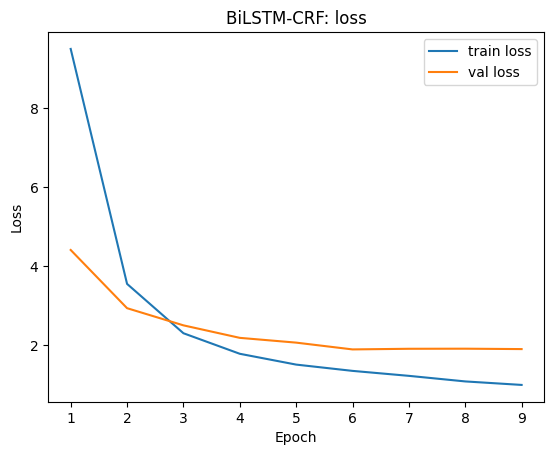

In [ ]:
# === Post-training: plots (loss / gap / LR) + validation metrics (F1, token accuracy) ===

# 1) Curves from `history`
hist = history.history
epochs = range(1, len(hist.get("loss", [])) + 1)

plt.figure()
plt.plot(epochs, hist.get("loss", []), label="train loss")
plt.plot(epochs, hist.get("val_loss", []), label="val loss")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.title("BiLSTM-CRF: loss"); plt.legend()
plt.show()

## Generalization gap
The generalization gap is the difference between validation and training loss at each epoch:

$$\text{gap} = loss_{val} - loss_{train}$$

A small gap (near zero) suggests the model fits training data and transfers well to unseen data. A growing positive gap indicates overfitting: training loss keeps dropping while validation loss stalls or rises. A negative gap (validation lower than training) can occur with strong regularization or augmentation that makes training examples harder than held-out data. Use the curve to spot when overfitting begins and to choose an early-stopping point (around the epoch with the lowest validation loss).

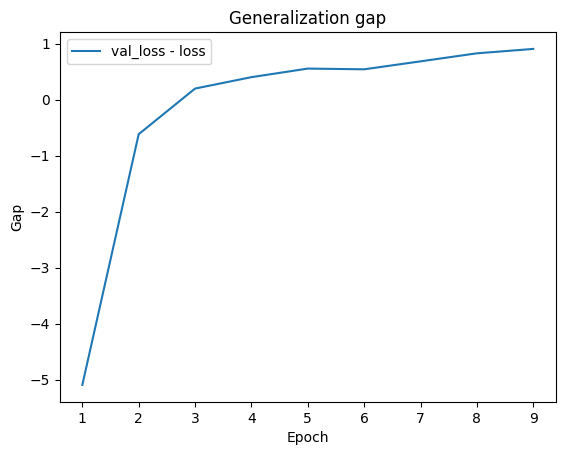

In [ ]:
if "loss" in hist and "val_loss" in hist and len(hist["loss"]) == len(hist["val_loss"]):
    gap = np.array(hist["val_loss"]) - np.array(hist["loss"])
    plt.figure()
    plt.plot(epochs, gap, label="val_loss - loss")
    plt.xlabel("Epoch"); plt.ylabel("Gap"); plt.title("Generalization gap"); plt.legend()
    plt.show()

## Learning rate

This curve comes from `ReduceLROnPlateau`, which watches `val_loss`. When `val_loss` stops improving for a set patience (here, 1 epoch), the callback multiplies the current learning rate by a factor (here, 0.5), down to `min_lr` (`1e-5`). The goal is to switch from larger exploratory steps to smaller, fine-tuning steps once the model reaches a plateau.

Typical pattern:
- Early epochs: higher learning rate with faster progress, larger updates.
- Plateau in `val_loss`: the callback lowers the learning rate with steadier, smaller updates that can reduce overshoot and overfitting.
- Multiple plateaus: multiple drops, until `min_lr` is reached or early stopping triggers.

If the rate drops too early or too often, we increase `patience` or use a smaller `factor`. If it never drops but `val_loss` is noisy, we consider smoothing (larger patience) or a slightly lower initial learning rate.


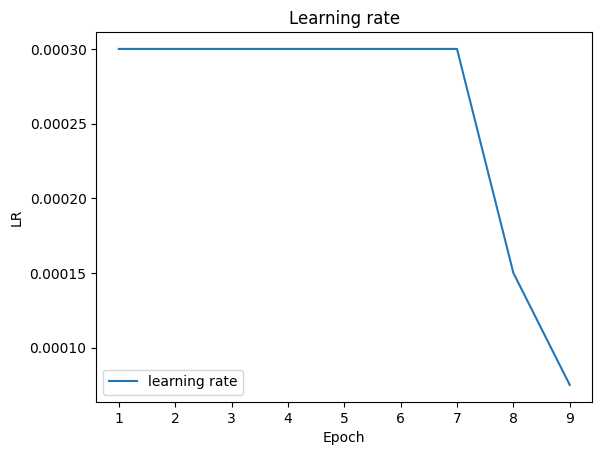

In [ ]:
if "learning_rate" in hist:
    plt.figure()
    plt.plot(epochs, hist["learning_rate"], label="learning rate")
    plt.xlabel("Epoch"); plt.ylabel("LR"); plt.title("Learning rate"); plt.legend()
    plt.show()

In [ ]:
# 2) Validation metrics
# Decode on validation
y_pred_val = model.decode(tf.convert_to_tensor(X_val))

# Map ids converted to BIO strings for seqeval
def to_label_seqs(y_ids, lengths):
    out = []
    for seq, l in zip(y_ids, lengths):
        l = int(l)
        out.append([str(id2label.get(int(t), "O")) for t in seq[:l]])
    return out

true_val = to_label_seqs(y_val, len_val)
pred_val = to_label_seqs(y_pred_val, len_val)

print("Validation F1 (seqeval):", f1_score(true_val, pred_val))
print(classification_report(true_val, pred_val))

# Token-level accuracy
def token_accuracy(y_true_ids, y_pred_ids, lengths):
    correct = 0
    total = 0
    for yt, yp, l in zip(y_true_ids, y_pred_ids, lengths):
        l = int(l)
        yt = np.asarray(yt[:l])
        yp = np.asarray(yp[:l])
        correct += int((yt == yp).sum())
        total += l
    return correct / max(total, 1)

print("Validation token accuracy:", token_accuracy(y_val, y_pred_val, len_val))

Validation F1 (seqeval): 0.8198890311566368
              precision    recall  f1-score   support

         LOC       0.88      0.79      0.83      5904
        MISC       0.81      0.71      0.76      4611
         ORG       0.83      0.79      0.81      3511
         PER       0.90      0.83      0.86      5593

   micro avg       0.86      0.78      0.82     19619
   macro avg       0.85      0.78      0.82     19619
weighted avg       0.86      0.78      0.82     19619

Validation token accuracy: 0.9760584573909992


### Test predictions, lengths, and trimming

`model.decode(X_test)` returns `y_pred` with shape `(B, T)`, where `B` is the number of test sentences and `T` is the fixed padded length `MAX_LEN`. Because every sentence is padded to length `T` for batching, the tail of many rows corresponds to padding rather than real tokens. The array `len_test` has shape `(B,)` and stores each sentence’s true token count before padding. When converting predictions to BIO labels, we slice each row to its first `len_test[i]` positions so that tags produced for padded slots are discarded. This trimming ensures the reported metrics reflect only genuine tokens, not padding.


In [ ]:
# --- Test evaluation ---
# Decode model predictions on the test set. Integer tag ids shaped (B, T)
# B = batch size (number of sequences/examples) and T = time steps / sequence length after padding.
y_pred = model.decode(tf.convert_to_tensor(X_test))  # (num_examples, max_len)

def to_label_seqs(y_ids, lengths):
    """
    Convert sequences of integer tag ids to BIO label strings,
    trimming each sequence to its true (unpadded) length so padding is ignored.
    """
    out = []
    for seq, l in zip(y_ids, lengths):
        l = int(l)  # true length for this example
        out.append([str(id2label[int(t)]) for t in seq[:l]])
    return out

# Convert ground truth and predictions to BIO string lists (one list per example)
true_seqs = to_label_seqs(y_test, len_test)
pred_seqs = to_label_seqs(y_pred, len_test)

# seqeval metrics: entity-level micro F1 and a detailed per-entity report
print("Test F1 (seqeval):", f1_score(true_seqs, pred_seqs))
print(classification_report(true_seqs, pred_seqs))

Test F1 (seqeval): 0.8249459380089169
              precision    recall  f1-score   support

         LOC       0.89      0.81      0.85      5955
        MISC       0.83      0.72      0.77      5060
         ORG       0.84      0.79      0.82      3449
         PER       0.90      0.82      0.86      5210

   micro avg       0.87      0.79      0.82     19674
   macro avg       0.87      0.78      0.82     19674
weighted avg       0.87      0.79      0.82     19674



## 8. Inference demo

In [ ]:
_tok = re.compile(r"\w+|[^\w\s]", re.UNICODE)

def predict_sentence(text):
    tokens = _tok.findall(text)
    x = np.array([encode_tokens(tokens)])
    x = pad_sequences(x, maxlen=MAX_LEN, padding="post", truncating="post", value=PAD_ID)
    pred_ids = model.decode(tf.convert_to_tensor(x))[0][:len(tokens)]
    return list(zip(tokens, [id2label[int(t)] for t in pred_ids]))

# NER examples (PER, ORG, LOC, MISC), tokenized with space-before-punctuation
examples = [
    "Barack Obama visited Paris with Apple executives .",
    "Angela Merkel met Emmanuel Macron in Berlin .",
    "Sundar Pichai discussed AI at Google in San Francisco .",
    "Microsoft acquired GitHub in Seattle .",
    "The University of Oxford collaborated with IBM in London .",
    "Lionel Messi signed with Paris Saint Germain after leaving Barcelona .",
    "The New York Times interviewed Jeff Bezos in Washington .",
    "Tesla opened a factory near Berlin , Germany .",
    "Amazon Web Services announced a partnership with Deloitte in Tokyo .",
    "NVIDIA and OpenAI presented research at NeurIPS in Vancouver .",
    "Pope Francis visited the United Arab Emirates .",
    "Harvard University partnered with MIT in Cambridge .",
    "The European Union met with NATO officials in Brussels .",
    "BBC reported that Novak Djokovic won in Melbourne .",
    "Sony Pictures collaborated with Marvel Studios in Los Angeles .",
    "NASA worked with SpaceX at Kennedy Space Center in Florida ."
]

for s in examples:
    print(s)
    print(predict_sentence(s))
    print()

Barack Obama visited Paris with Apple executives .
[('Barack', 'B-PER'), ('Obama', 'I-PER'), ('visited', 'O'), ('Paris', 'B-LOC'), ('with', 'O'), ('Apple', 'B-ORG'), ('executives', 'O'), ('.', 'O')]

Angela Merkel met Emmanuel Macron in Berlin .
[('Angela', 'B-PER'), ('Merkel', 'I-PER'), ('met', 'O'), ('Emmanuel', 'B-PER'), ('Macron', 'I-PER'), ('in', 'O'), ('Berlin', 'B-LOC'), ('.', 'O')]

Sundar Pichai discussed AI at Google in San Francisco .
[('Sundar', 'O'), ('Pichai', 'O'), ('discussed', 'O'), ('AI', 'B-MISC'), ('at', 'O'), ('Google', 'B-ORG'), ('in', 'O'), ('San', 'B-LOC'), ('Francisco', 'I-LOC'), ('.', 'O')]

Microsoft acquired GitHub in Seattle .
[('Microsoft', 'B-ORG'), ('acquired', 'O'), ('GitHub', 'B-MISC'), ('in', 'O'), ('Seattle', 'B-LOC'), ('.', 'O')]

The University of Oxford collaborated with IBM in London .
[('The', 'O'), ('University', 'B-ORG'), ('of', 'I-ORG'), ('Oxford', 'I-ORG'), ('collaborated', 'O'), ('with', 'O'), ('IBM', 'B-ORG'), ('in', 'I-ORG'), ('London', '

In [ ]:
# BIO spans helper
def bio_spans(tokens, tags):
    spans, i = [], 0
    while i < len(tokens):
        tag = tags[i]
        if tag.startswith("B-"):
            typ = tag[2:]
            j = i + 1
            while j < len(tokens) and tags[j] == f"I-{typ}":
                j += 1
            spans.append((typ, i, j, " ".join(tokens[i:j])))
            i = j
        else:
            i += 1
    return spans

# NER examples (PER, ORG, LOC, MISC), tokenized with space-before-punctuation
examples = [
    "Barack Obama visited Paris with Apple executives .",
    "Angela Merkel met Emmanuel Macron in Berlin .",
    "Sundar Pichai discussed AI at Google in San Francisco .",
    "Microsoft acquired GitHub in Seattle .",
    "The University of Oxford collaborated with IBM in London .",
    "Lionel Messi signed with Paris Saint Germain after leaving Barcelona .",
    "The New York Times interviewed Jeff Bezos in Washington .",
    "Tesla opened a factory near Berlin , Germany .",
    "Amazon Web Services announced a partnership with Deloitte in Tokyo .",
    "NVIDIA and OpenAI presented research at NeurIPS in Vancouver .",
    "Pope Francis visited the United Arab Emirates .",
    "Harvard University partnered with MIT in Cambridge .",
    "The European Union met with NATO officials in Brussels .",
    "BBC reported that Novak Djokovic won in Melbourne .",
    "Sony Pictures collaborated with Marvel Studios in Los Angeles .",
    "NASA worked with SpaceX at Kennedy Space Center in Florida ."
]

# Run spans on each example
for s in examples:
    pairs = predict_sentence(s)
    toks, tg = zip(*pairs) if pairs else ([], [])
    spans = bio_spans(list(toks), list(tg))
    print(s)
    for typ, i, j, surface in spans:
        print(f"  {typ}: [{i}:{j}] '{surface}'")
    if not spans:
        print("  (no entities found)")
    print()

Barack Obama visited Paris with Apple executives .
  PER: [0:2] 'Barack Obama'
  LOC: [3:4] 'Paris'
  ORG: [5:6] 'Apple'

Angela Merkel met Emmanuel Macron in Berlin .
  PER: [0:2] 'Angela Merkel'
  PER: [3:5] 'Emmanuel Macron'
  LOC: [6:7] 'Berlin'

Sundar Pichai discussed AI at Google in San Francisco .
  MISC: [3:4] 'AI'
  ORG: [5:6] 'Google'
  LOC: [7:9] 'San Francisco'

Microsoft acquired GitHub in Seattle .
  ORG: [0:1] 'Microsoft'
  MISC: [2:3] 'GitHub'
  LOC: [4:5] 'Seattle'

The University of Oxford collaborated with IBM in London .
  ORG: [1:4] 'University of Oxford'
  ORG: [6:9] 'IBM in London'

Lionel Messi signed with Paris Saint Germain after leaving Barcelona .
  PER: [0:2] 'Lionel Messi'
  PER: [4:7] 'Paris Saint Germain'
  LOC: [9:10] 'Barcelona'

The New York Times interviewed Jeff Bezos in Washington .
  ORG: [1:4] 'New York Times'
  PER: [5:7] 'Jeff Bezos'
  LOC: [8:9] 'Washington'

Tesla opened a factory near Berlin , Germany .
  LOC: [0:1] 'Tesla'
  LOC: [5:6] 'Be

## Discussion of results

We trained a BiLSTM encoder with a linear-chain CRF from scratch on Babelscape/wikineural (EN) and evaluated with seqeval on the held-out test split. The model reached an overall test F1 of about 0.825, with the expected per-class pattern: PER highest (≈0.86), LOC close behind (≈0.85), ORG solid (≈0.82), and MISC the lowest (≈0.77). Precision is higher than recall across classes, which suggests the decoder is slightly conservative; fewer spurious entities, but it misses some true spans.

Qualitatively, the model handles many multi-token entities and long names correctly. Examples that came out well include “University of Oxford” (ORG), “New York Times” (ORG), “Jeff Bezos” (PER), “United Arab Emirates” (LOC), “Los Angeles” (LOC), and “Kennedy Space Center” (LOC). This is consistent with CRF sequence constraints helping the model keep `B-`/`I-` continuity inside spans.

Most errors fall into three common buckets:

1) Span boundary mistakes.  
   The model sometimes over- or under-extends an entity. For instance, “IBM in London” was labeled as a single ORG span, absorbing the preposition and location. In “Pope Francis,” only “Francis” was tagged PER, leaving “Pope” outside the span. These are typical boundary decisions where context is subtle and guidelines differ across corpora.

2) Type confusions.  
   Capitalized tokens that can be organizations or places are sometimes mislabeled. “Tesla” was tagged LOC instead of ORG, and “Cambridge” appeared as ORG rather than LOC. Ambiguous tokens like “Washington” were correctly handled as LOC in the example shown, but this class of ambiguity is a frequent source of errors without richer features.

3) Heterogeneous MISC.  
   The MISC class covers a grab-bag of categories and naturally scores lower. The model’s performance there reflects both label noisiness and the lack of specialized features.

These behaviors make sense given the architecture and inputs. The model relies on learned word embeddings plus context from the BiLSTM, with the CRF enforcing label consistency; there are no character-level cues for morphology or capitalization features beyond what embeddings capture, and no pretrained lexical knowledge. As a result, it performs strongly on clear, well-formed names (especially PER and LOC) and occasionally slips on boundaries or fine-grained type decisions.

For a tutorial-level system, the outcome is robust and readable: it recognizes entities in realistic sentences, keeps spans mostly coherent, and avoids many gratuitous false positives. If future improvements are desired, straightforward extensions such as character CNN/LSTM features, pretrained word vectors, lightweight casing features, or a modest increase in LSTM size would typically reduce the boundary and type confusions without changing the overall design. A switch to a pretrained transformer encoder would push F1 substantially higher but goes beyond the scope of this BiLSTM-CRF tutorial.


## 9. Save model & label map

In [ ]:
# Save weights + vocab/labels (recommended for subclassed models)

save_dir = "bilstm_crf_saved"
os.makedirs(save_dir, exist_ok=True)

# Weights only
model.save_weights(os.path.join(save_dir, "bilstm_crf.weights.h5"))

# Mappings
with open(os.path.join(save_dir, "word2id.json"), "w") as f:
    json.dump(word2id, f, ensure_ascii=False, indent=2)
with open(os.path.join(save_dir, "id2label.json"), "w") as f:
    json.dump({int(k): v for k, v in id2label.items()}, f, ensure_ascii=False, indent=2)

print("Saved to", save_dir)

Saved to bilstm_crf_saved


## Notes
- Uses a custom, pure-TensorFlow CRF: `LinearChainCRF` (layer) + `NERTagger` (model). The model Classes were generated using GPT-5.
- Dataset: **Babelscape/wikineural (English)** with provided `train_en / val_en / test_en` splits. Labels are 9-label BIO (`O, B/I-PER, B/I-ORG, B/I-LOC, B/I-MISC`).
- Masking: the model builds its mask from `PAD_ID` automatically; label padding uses `O`. For metrics, sequences are trimmed with `len_*`.
- Regularization: `SpatialDropout1D` on embeddings, mild L2 on embeddings/dense and CRF transitions, and `EarlyStopping`/`ReduceLROnPlateau` on `val_loss`. Optional on-the-fly word-dropout (replace some tokens with `<UNK>`).
- Performance: keep `recurrent_dropout=0` on LSTMs to stay on the CuDNN fast path; adjust batch size/`MAX_LEN` as needed. A warm-build (one dummy forward pass) creates weights before `model.summary()` and training.
- Tokenization: `_tok` regex (`\w+|[^\w\s]`) and examples use space-before-punctuation to keep tokens aligned.

---

### Further reading
- Linear-chain CRFs (foundations): Lafferty, McCallum, Pereira (2001).
- BiLSTM-CRF for NER: Huang, Xu, Yu (2015).
- `seqeval` documentation for BIO evaluation.
- Babelscape WikiNEuRal dataset card (English splits and BIO schema).
